In [3]:
import bilby
import numpy as np
import pickle as pkl
from tqdm import tqdm
from matplotlib import pyplot as plt

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=16)

TRUE_LN_LIKE = -2749.91122972
colors = ["#000000","#b00069",'#00B862',"#0d2ec1",'#F7005A']

def show_spins(nnodes, nevents=1000, log=False, show_lightning=False, save=False):

    varcut = f'../../data/gw/results/new_flexible_models_salvo_pe/pin_extra_params_varcut1_nnodes_{nnodes}_nevents_{nevents}_nvt_4000M_npe_16000/peseed_0_vtseed_0/sample_posterior_spin_mag.pkl'
    neff10 = f'../../data/gw/results/new_flexible_models_salvo_pe/pin_extra_params_MinimumNeff10_nnodes_{nnodes}_nevents_{nevents}_nvt_4000M_npe_16000/peseed_0_vtseed_0/sample_posterior_spin_mag.pkl'
    neff30 = f'../../data/gw/results/new_flexible_models_salvo_pe/pin_extra_params_MinimumNeff30_nnodes_{nnodes}_nevents_{nevents}_nvt_4000M_npe_16000/peseed_0_vtseed_0/sample_posterior_spin_mag.pkl'

    fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(6,8), sharex=True)

    labels = ['Variance $< 1$', '$N_{\\rm eff} > 30$', '$N_{\\rm eff} > 10$']

    for ii, filepath in enumerate([varcut, neff30, neff10]):
        with open(filepath, 'rb') as ff:
            spins_dict = pkl.load(ff)

        if show_lightning:
            for count in np.random.choice(len(spins_dict['p_a']), 500, replace=False):
                y = spins_dict['p_a'][count]
                ax[ii].plot(spins_dict['a'], y, color=colors[1], linestyle='solid', linewidth=0.2, alpha=0.1)
            ax[ii].plot(spins_dict['a'], -y - 10, color=colors[1], linestyle='solid', label=labels[ii])
        else:
            ax[ii].fill_between(spins_dict['a'], np.percentile(spins_dict['p_a'], 5, axis=0), np.percentile(spins_dict['p_a'], 95, axis=0), color=colors[1], alpha=0.2, label=labels[ii])
            ax[ii].plot(spins_dict['a'], np.median(spins_dict['p_a'], axis=0), color=colors[1], linestyle='solid')
        
        ax[ii].plot(spins_dict['a'], spins_dict['truth'], 'k-', label='Truth')
        ax[ii].legend(borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)

        ax[ii].set_xlim(0,1)
        ax[ii].set_ylabel('$p(\chi)$')
        if log:
            ax[ii].set_yscale('log')
        
    if not log:
        ax[0].set_ylim(0,6)
        ax[1].set_ylim(0,10)
        ax[2].set_ylim(0,14)

    ax[2].set_xlabel('$\chi$')

    plt.tight_layout()
    if save:
        import os
        os.makedirs('../../draft/plots/gw/spins', exist_ok=True)
        plt.savefig(f'../../draft/plots/gw/spins/comparison_{nnodes}nodes_flexible.pdf')
    plt.show()

def show_overlay_spins(nnodes, nevents=1000, log=False):

    varcut = f'../../data/gw/results/new_flexible_models_salvo_pe/pin_extra_params_varcut1_nnodes_{nnodes}_nevents_{nevents}_nvt_4000M_npe_16000/peseed_0_vtseed_0/sample_posterior_spin_mag.pkl'
    neff10 = f'../../data/gw/results/new_flexible_models_salvo_pe/pin_extra_params_MinimumNeff10_nnodes_{nnodes}_nevents_{nevents}_nvt_4000M_npe_16000/peseed_0_vtseed_0/sample_posterior_spin_mag.pkl'
    neff30 = f'../../data/gw/results/new_flexible_models_salvo_pe/pin_extra_params_MinimumNeff30_nnodes_{nnodes}_nevents_{nevents}_nvt_4000M_npe_16000/peseed_0_vtseed_0/sample_posterior_spin_mag.pkl'

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,4), sharex=True)

    labels = ['Variance $< 1$', '$N_{\\rm eff} > 30$', '$N_{\\rm eff} > 10$']

    for ii, filepath in enumerate([varcut, neff30, neff10]):
        with open(filepath, 'rb') as ff:
            spins_dict = pkl.load(ff)
        if ii == 0:
            ax.fill_between(spins_dict['a'], np.percentile(spins_dict['p_a'], 5, axis=0), np.percentile(spins_dict['p_a'], 95, axis=0), color=colors[ii+1], alpha=0.2, label=labels[ii])
        else:
            ax.plot(spins_dict['a'], np.percentile(spins_dict['p_a'], 5, axis=0), linestyle='dashed', color=colors[ii+1], label=labels[ii])
            ax.plot(spins_dict['a'], np.percentile(spins_dict['p_a'], 95, axis=0), linestyle='dashed', color=colors[ii+1])
        
    ax.plot(spins_dict['a'], spins_dict['truth'], 'k-', label='Truth')
    if log:
        ax.set_yscale('log')
        
    if not log:
        ax.set_ylim(0,14)
    ax.set_xlim(0,1)
    ax.set_ylabel('$p(\chi)$')
    ax.set_xlabel('$\chi$')
    ax.legend(borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)
    plt.tight_layout()
    # plt.savefig('spins.pdf')
    plt.show()

from scipy.stats import beta as beta_scipy
def show_strong_model_spins(nvts, npes, seedss, nevents=1000, save=False, fill=True):

    fig = plt.figure(figsize=(10,2.75*len(nvts)))
    subfigs = fig.subfigures(nrows=len(nvts), ncols=1, hspace=-0.15)
    for k in range(len(nvts)):
        subfig = subfigs[k]
        
        nvt = nvts[k]
        npe = npes[k]
        seeds = seedss[k]
        expo = int(np.log10(nvt))
        mult = nvt / 10**expo
        if int(mult) == mult:
            mult = int(mult)
        if mult == 1:
            nvtformat = f'10^{{{expo+6}}}'
        else:
            nvtformat = f'{mult} \\times 10^{{{expo+6}}}'
            
        subfig.suptitle(f'$N_{{\\rm obs}}={nevents}, N_{{\\rm PE}}={npe}, N_{{\\rm inj}}={nvtformat}$', y=0.97)
        axes = subfig.subplots(nrows=1, ncols=2, width_ratios=[1,0.5])
        ax = axes[0]
        vax = axes[1]
        erros, mean_vars = [], []
        for ii in tqdm(range(seeds)):
            filepath = f'../../data/gw/results/OnlySpin_nevents_{nevents}_nvt_{nvt}M_npe_{npe}/peseed_{ii}_vtseed_{ii}/sample_posterior_result.json'
            result = bilby.core.result.read_in_result(filepath)
            ms, vs = result.posterior['mu_chi'], result.posterior['sigma_chi']

            a = np.linspace(0,1,1000)
            p_a = []
            for m, v in zip(ms, vs):
                nu = (m*(1-m) / v) - 1
                alpha, beta = nu*m, nu*(1-m)
                p_a.append(beta_scipy.pdf(a, alpha, beta))

            if fill:
                ax.fill_between(a, np.percentile(p_a, 5, axis=0), np.percentile(p_a, 95, axis=0), color=colors[1], alpha=0.1)
            else:
                ax.plot(a, np.percentile(p_a, 5, axis=0), color=colors[1], linestyle='dashed')
                ax.plot(a, np.percentile(p_a, 95, axis=0), color=colors[1], linestyle='dotted')

            with open(filepath.replace('result.json', 'error_statistics.txt'), 'r') as ff:
                fil = ff.read().split('\n')
                prec = float(fil[2].split('\t')[-1])
                accu = float(fil[3].split('\t')[-1])
                erro = float(fil[4].split('\t')[-1])
                try:
                    mean_var = float(fil[5].split('\t')[-1])
                except:
                    mean_var = 0.
            erros.append(erro)
            mean_vars.append(mean_var)
        ax.plot(a, -1-np.percentile(p_a, 5, axis=0), color=colors[1], linestyle='dashed', label='5th')
        ax.plot(a, -1-np.percentile(p_a, 95, axis=0), color=colors[1], linestyle='dotted', label='95th')
        vax.fill_betweenx([0,20], [0,0], [0.2,0.2], color=colors[3], label='$\hat{E}[\hat{p}] < 0.2$', alpha=0.2, linestyle='dashed')
        vax.fill_betweenx([0,1], [0,0], [1,1], color=colors[0], label='$\int \hat{\sigma}^2\hat{p} < 1$', alpha=0.2, linestyle='dashed')
        
        truth = beta_scipy.pdf(a, 1.67, 4.43)
        ax.plot(a, truth, 'k-', label='Truth')
        
        ax.set_xlim(0,1)
        ax.set_ylabel('$p(\chi)$')
        ax.set_ylim(0,3)

        vax.scatter(erros, mean_vars, color=colors[1], s=2)
        vax.set_ylabel('$\int\hat{\sigma}^2\hat{p}$')
        vax.set_yscale('log')

        vax.set_xscale('log')
        vax.set_xlim(0.01,1)
        vax.set_ylim(0.5,13)
        if k == 0:
            ax.legend(borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)
            vax.legend(loc='lower right', borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)
    
    ax.set_xlabel('$\chi$')
    vax.set_xlabel('$\hat{E}[\hat{p}]$ [bits]')
    
    plt.subplots_adjust(bottom=0.25, top=0.85, wspace=0.3)
    # plt.tight_layout()
    if save:
        import os
        os.makedirs('../../draft/plots/gw/spins', exist_ok=True)
        if nevents==1000:
            plt.savefig(f'../../draft/plots/gw/spins/comparison_strong.pdf')
        else:
            plt.savefig(f'../../draft/plots/gw/spins/nevents_{nevents}_comparison_strong.pdf')
    plt.show()

def show_weak_model_spins(thresholds, nvt, npe, seeds, nevents=1000, save=False, fill=True):
    
    fig = plt.figure(figsize=(10,2.75*len(thresholds)))
    subfigs = fig.subfigures(nrows=len(thresholds), ncols=1, hspace=-0.15)
    for k in range(len(thresholds)):
        if len(thresholds) == 1:
            subfig = subfigs
        else:
            subfig = subfigs[k]
        
        threshold = thresholds[k]

        if 'MinimumNeff' in threshold:
            val = int(threshold.replace('MinimumNeff', ''))
            title = f'$N_{{{{\\rm eff}}, p}} > {val}$, $N_{{{{\\rm eff}}, \\xi}} > 4N_{{\\rm obs}}$, '
        elif 'varcut1' in threshold:
            title = '$\hat{\sigma}^2 < 1$, '
        elif 'varcut0p5' in threshold:
            title = '$\hat{\sigma}^2 < 0.5$, '
        else:
            title = 'No threshold, '

        if 'comparison' in threshold:
            assert k == len(thresholds) - 1
            nvt = 4000
            npe = 16000
            seeds = 1
        expo = int(np.log10(nvt))
        mult = nvt / 10**expo
        if int(mult) == mult:
            mult = int(mult)
        if mult == 1:
            nvtformat = f'10^{{{expo+6}}}'
        else:
            nvtformat = f'{mult} \\times 10^{{{expo+6}}}'
                
        base_title = f'$N_{{\\rm obs}}={nevents}, N_{{\\rm PE}}={npe}, N_{{\\rm inj}}={nvtformat}$'

        subfig.suptitle(title + base_title, y=0.97)
        axes = subfig.subplots(nrows=1, ncols=2, width_ratios=[1,0.5])
        ax = axes[0]
        vax = axes[1]
        erros, mean_vars = [], []
        if len(threshold) >= 1:
            threshold += '_'
        for ii in tqdm(range(seeds)):
            try:
                if 'comparison' in threshold:
                    filepath = f'../../data/gw/results/semiparametric_models_salvo_pe_uniformPrior/pin_extra_params_nnodes_10_nevents_{nevents}_nvt_4000M_npe_16000/peseed_{ii}_vtseed_{ii}/sample_posterior_nlive300_spin_mag.pkl'
                else:
                    filepath = f'../../data/gw/results/semiparametric_models_salvo_pe_uniformPrior/pin_extra_params_{threshold}nnodes_10_nevents_{nevents}_nvt_{nvt}M_npe_{npe}/peseed_{ii}_vtseed_{ii}/sample_posterior_nlive300_spin_mag.pkl'
                with open(filepath, 'rb') as ff:
                    spins_dict = pkl.load(ff)
            except:
                filepath = f'../../data/gw/results/semiparametric_models_salvo_pe_uniformPrior/pin_extra_params_{threshold.replace("30","10")}nnodes_10_nevents_{nevents}_nvt_{nvt}M_npe_{npe}/peseed_{ii}_vtseed_{ii}/RejectionedToNeff{threshold.replace("MinimumNeff","").replace("_","")}.0_sample_posterior_nlive300_spin_mag.pkl'
                with open(filepath, 'rb') as ff:
                    spins_dict = pkl.load(ff)
            # print(filepath)
            ax.plot(spins_dict['a'], np.percentile(spins_dict['p_a'], 5, axis=0), color=colors[1], linestyle='dashed')
            ax.plot(spins_dict['a'], np.percentile(spins_dict['p_a'], 95, axis=0), color=colors[1], linestyle='dotted')
        
            with open(filepath.replace('spin_mag.pkl', 'error_statistics.txt'), 'r') as ff:
                fil = ff.read().split('\n')
                prec = float(fil[2].split('\t')[-1])
                accu = float(fil[3].split('\t')[-1])
                erro = float(fil[4].split('\t')[-1])
                try:
                    mean_var = float(fil[5].split('\t')[-1])
                except:
                    mean_var = 0.
            erros.append(erro)
            mean_vars.append(mean_var)

        ax.plot(spins_dict['a'], -1-np.percentile(spins_dict['p_a'], 5, axis=0), color=colors[1], linestyle='dashed', label='5th')
        ax.plot(spins_dict['a'], -1-np.percentile(spins_dict['p_a'], 95, axis=0), color=colors[1], linestyle='dotted', label='95th')

        vax.fill_betweenx([0,20], [0,0], [0.2,0.2], color=colors[3], label='$\hat{E}[\hat{p}] < 0.2$', alpha=0.2, linestyle='dashed')
        vax.fill_betweenx([0,1], [0,0], [100,100], color=colors[0], label='$\int \hat{\sigma}^2\hat{p} < 1$', alpha=0.2, linestyle='dashed')
        
        ax.plot(spins_dict['a'], spins_dict['truth'], 'k-', label='Truth')
        
        ax.set_xlim(0,1)
        ax.set_ylabel('$p(\chi)$')
        ax.set_ylim(0,7)

        vax.scatter(erros, mean_vars, color=colors[1], s=2)
        vax.set_ylabel('$\int\hat{\sigma}^2\hat{p}$')
        vax.set_yscale('log')

        vax.set_xscale('log')
        vax.set_xlim(0.05,5)
        vax.set_ylim(0.5,13)
        if k == 0:
            ax.legend(borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)
            vax.legend(loc='lower right', borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)
    
    ax.set_xlabel('$\chi$')
    vax.set_xlabel('$\hat{E}[\hat{p}]$ [bits]')
    
    plt.subplots_adjust(bottom=0.25, top=0.85, wspace=0.3)
    # plt.tight_layout()
    if save:
        import os
        os.makedirs('../../draft/plots/gw/spins', exist_ok=True)
        if nevents==1000:
            plt.savefig(f'../../draft/plots/gw/spins/uniform_prior_comparison_weak.pdf')
        else:
            plt.savefig(f'../../draft/plots/gw/spins/uniform_prior_nevents_{nevents}_comparison_weak.pdf')
    plt.show()

# show_spins(10)
# show_spins(20)

100%|██████████| 4/4 [00:00<00:00,  8.57it/s]


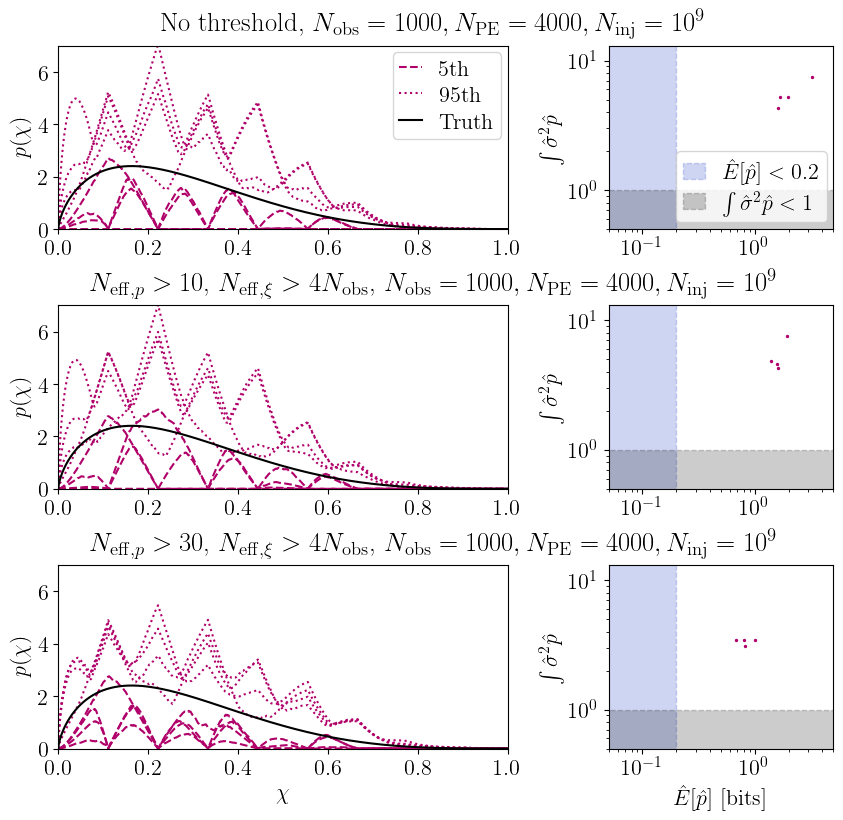

In [4]:
nvt = 1000
npe = 4000
seeds = 4
thresholds = ['', 'MinimumNeff10', 'MinimumNeff30']
# show_weak_model_spins(thresholds, nvt, npe, seeds, save=True, fill=False)
show_weak_model_spins(thresholds, nvt, npe, seeds, nevents=1000, save=True, fill=False)


100%|██████████| 4/4 [00:00<00:00, 37.49it/s]


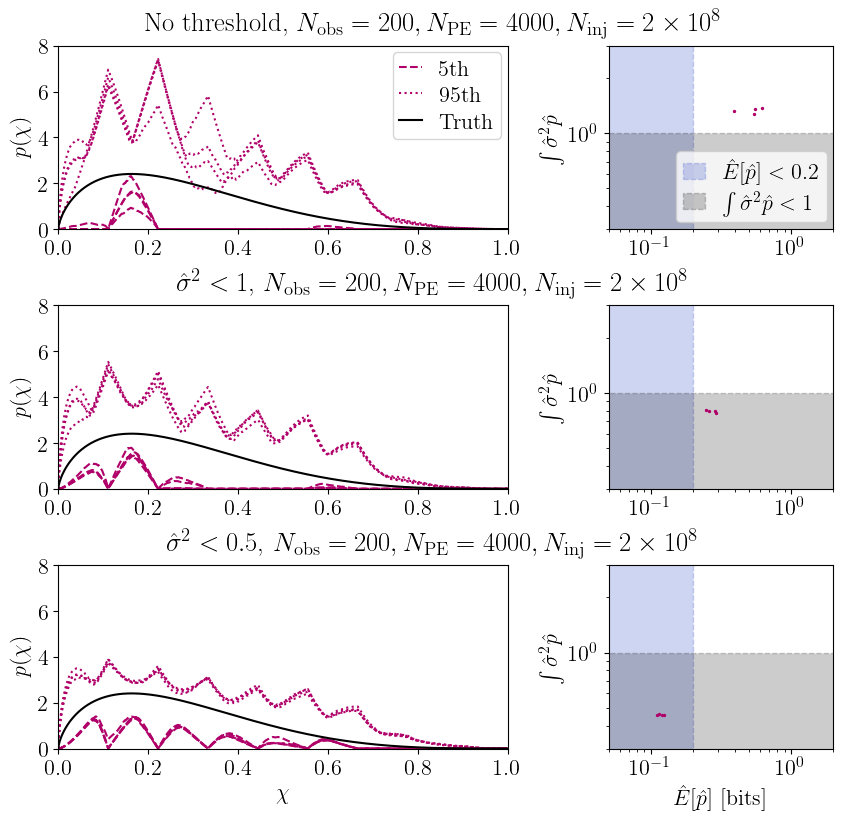

In [4]:
thresholds = ['', 'varcut1', 'varcut0p5']
npe = 4000
nvt = 200
seeds = 4
fig = plt.figure(figsize=(10,2.75*len(thresholds)))
subfigs = fig.subfigures(nrows=len(thresholds), ncols=1, hspace=-0.15)
for k in range(len(thresholds)):
    if len(thresholds) == 1:
        subfig = subfigs
    else:
        subfig = subfigs[k]
    
    threshold = thresholds[k]

    if 'MinimumNeff' in threshold:
        val = int(threshold.replace('MinimumNeff', ''))
        title = f'$N_{{\\rm eff}} > {val}$, '
    elif 'varcut1' in threshold:
        title = '$\hat{\sigma}^2 < 1$, '
    elif 'varcut0p7' in threshold:
        title = '$\hat{\sigma}^2 < 0.7$, '
    elif 'varcut0p5' in threshold:
        title = '$\hat{\sigma}^2 < 0.5$, '
    
    else:
        title = 'No threshold, '

    if 'comparison' in threshold:
        assert k == len(thresholds) - 1
        nvt = 4000
        npe = 16000
        seeds = 1
    expo = int(np.log10(nvt))
    mult = nvt / 10**expo
    if int(mult) == mult:
        mult = int(mult)
    if mult == 1:
        nvtformat = f'10^{{{expo+6}}}'
    else:
        nvtformat = f'{mult} \\times 10^{{{expo+6}}}'
            
    base_title = f'$N_{{\\rm obs}}=200, N_{{\\rm PE}}={npe}, N_{{\\rm inj}}={nvtformat}$'

    subfig.suptitle(title + base_title, y=0.97)
    axes = subfig.subplots(nrows=1, ncols=2, width_ratios=[1,0.5])
    ax = axes[0]
    vax = axes[1]
    erros, mean_vars = [], []
    if len(threshold) >= 1:
        threshold += '_'
    for ii in tqdm(range(seeds)):
        try:
            if 'comparison' in threshold:
                filepath = f'../../data/gw/results/semiparametric_models_salvo_pe_uniformPrior/pin_extra_params_nnodes_10_nevents_200_nvt_4000M_npe_16000/peseed_{ii}_vtseed_{ii}/sample_posterior_nlive500_spin_mag.pkl'
            else:
                filepath = f'../../data/gw/results/semiparametric_models_salvo_pe_uniformPrior/pin_extra_params_{threshold}nnodes_10_nevents_200_nvt_{nvt}M_npe_{npe}/peseed_{ii}_vtseed_{ii}/sample_posterior_nlive300_spin_mag.pkl'
            with open(filepath, 'rb') as ff:
                spins_dict = pkl.load(ff)
        except:
            filepath = f'../../data/gw/results/semiparametric_models_salvo_pe_uniformPrior/pin_extra_params_{threshold.replace("30","10")}nnodes_10_nevents_200_nvt_{nvt}M_npe_{npe}/peseed_{ii}_vtseed_{ii}/RejectionedToNeff{threshold.replace("MinimumNeff","").replace("_","")}.0_sample_posterior_nlive300_spin_mag.pkl'
            with open(filepath, 'rb') as ff:
                spins_dict = pkl.load(ff)
        # print(filepath)
        ax.plot(spins_dict['a'], np.percentile(spins_dict['p_a'], 5, axis=0), color=colors[1], linestyle='dashed')
        ax.plot(spins_dict['a'], np.percentile(spins_dict['p_a'], 95, axis=0), color=colors[1], linestyle='dotted')
    
        with open(filepath.replace('spin_mag.pkl', 'error_statistics.txt'), 'r') as ff:
            fil = ff.read().split('\n')
            prec = float(fil[2].split('\t')[-1])
            accu = float(fil[3].split('\t')[-1])
            erro = float(fil[4].split('\t')[-1])
            try:
                mean_var = float(fil[5].split('\t')[-1])
            except:
                mean_var = 0.
        erros.append(erro)
        mean_vars.append(mean_var)

    ax.plot(spins_dict['a'], -1-np.percentile(spins_dict['p_a'], 5, axis=0), color=colors[1], linestyle='dashed', label='5th')
    ax.plot(spins_dict['a'], -1-np.percentile(spins_dict['p_a'], 95, axis=0), color=colors[1], linestyle='dotted', label='95th')

    vax.fill_betweenx([0,20], [0,0], [0.2,0.2], color=colors[3], label='$\hat{E}[\hat{p}] < 0.2$', alpha=0.2, linestyle='dashed')
    vax.fill_betweenx([0,1], [0,0], [100,100], color=colors[0], label='$\int \hat{\sigma}^2\hat{p} < 1$', alpha=0.2, linestyle='dashed')
    
    ax.plot(spins_dict['a'], spins_dict['truth'], 'k-', label='Truth')
    
    ax.set_xlim(0,1)
    ax.set_ylabel('$p(\chi)$')
    ax.set_ylim(0,8)

    vax.scatter(erros, mean_vars, color=colors[1], s=2)
    vax.set_ylabel('$\int\hat{\sigma}^2\hat{p}$')
    vax.set_yscale('log')

    vax.set_xscale('log')
    vax.set_xlim(0.05,2)
    vax.set_ylim(0.3,3)
    vax.set_yticks([1], minor=False)
    vax.set_yticks([0.3,0.4,0.5,0.6,0.7,0.8, 0.9, 2, 3], ['','','','','','','','',''], minor=True)
    
    
    if k == 0:
        ax.legend(borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)
        vax.legend(loc='lower right', borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)

ax.set_xlabel('$\chi$')
vax.set_xlabel('$\hat{E}[\hat{p}]$ [bits]')

plt.subplots_adjust(bottom=0.25, top=0.85, wspace=0.3)
# plt.tight_layout()
plt.savefig(f'../../draft/plots/gw/spins/uniform_prior_comparison_weak_vs_varcut.pdf')
plt.show()

100%|██████████| 1/1 [00:01<00:00,  1.14s/it]


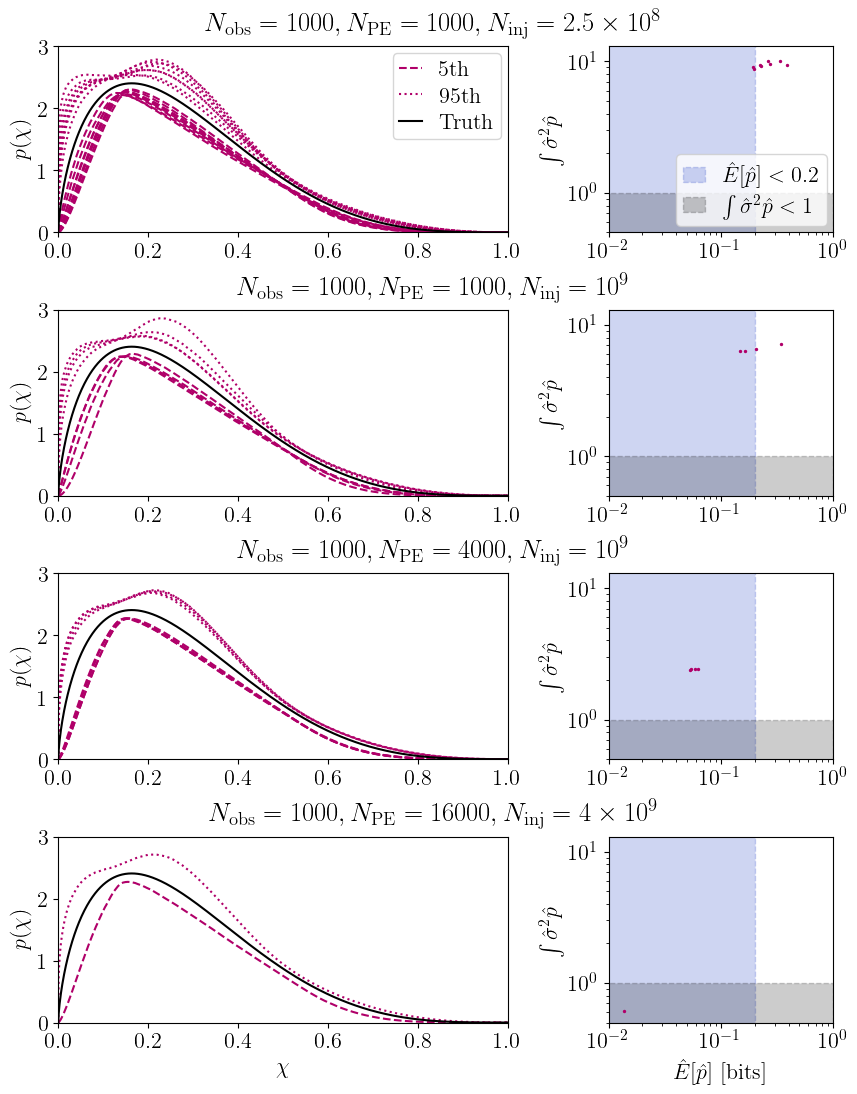

In [6]:
nvts = [250, 1000, 1000, 4000]
npes = [1000, 1000, 4000, 16000]
seedss = [8, 4, 4, 1]
show_strong_model_spins(nvts, npes, seedss, save=True, fill=False)


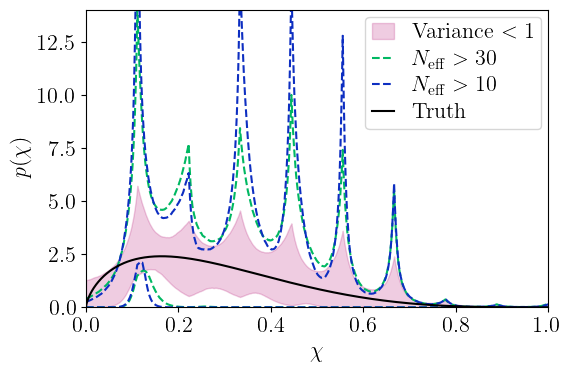

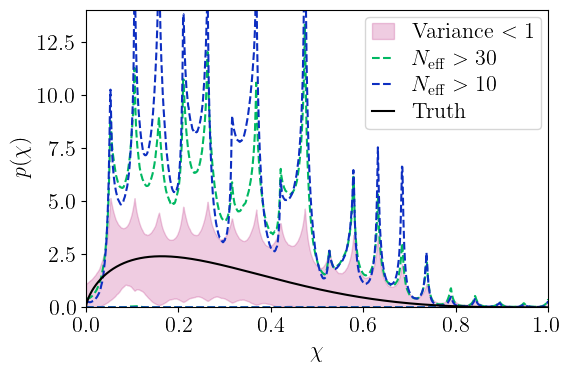

In [138]:
show_overlay_spins(10)
show_overlay_spins(20)

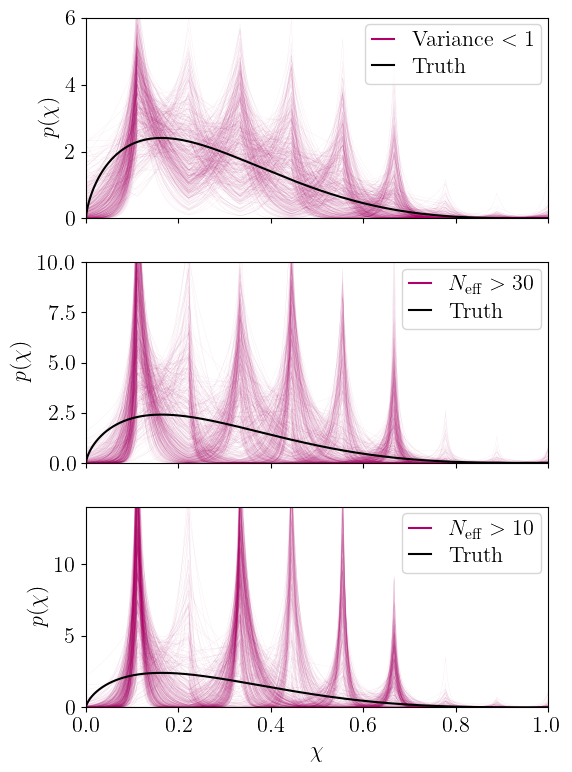

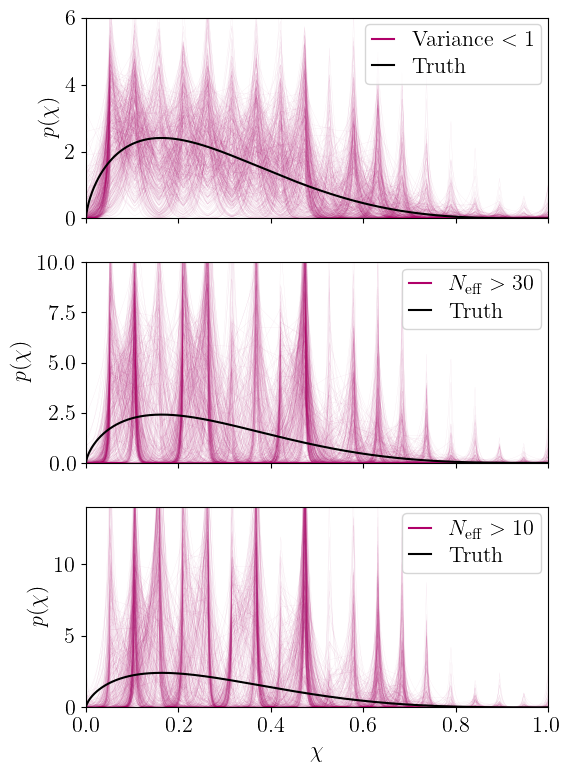

In [32]:
show_spins(10, show_lightning=True, save=True)
show_spins(20, show_lightning=True, save=True)